<a href="https://colab.research.google.com/github/ljm0616/Capstone_project/blob/main/Fish_Market_Pandas_Seaborn_EDA_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fish Market 데이터로 익히는 Pandas·Seaborn EDA

> **분석 상황:** 어류의 신체 측정값으로 무게를 예측하는 모델을 만들기 전에, 데이터가 어떤 모습인지 파악하고 모델이 사용할 수 있는 상태로 정리하려고 합니다.

이 노트북의 범위는 **탐색적 데이터 분석(EDA)과 데이터 전처리**입니다. 머신러닝 모델을 학습하거나 성능을 평가하지 않고, 입력 변수 `X`와 타겟 `y`를 준비하는 단계에서 마칩니다.

각 실습은 다음 순서로 진행합니다.

1. **시나리오:** 무엇을 확인하며, 그 확인이 왜 필요한지 이해합니다.
2. **AI에게 요청할 프롬프트:** 구현 방법을 지시하지 않고 분석 의도와 원하는 결과를 자연어로 설명합니다.
3. **코드 셀:** AI가 제안할 수 있는 대표 코드를 실행합니다. 같은 결과를 만드는 다른 코드도 정답일 수 있습니다.
4. **결과 확인 및 해석:** 출력이 분석 과정에서 무엇을 의미하는지 판단합니다.

## 데이터 설명

Fish Market 데이터는 여러 어종의 무게와 신체 치수를 기록한 표 형식 데이터입니다. 실습용 파일에는 결측치 처리 과정을 연습할 수 있도록 일부 측정값에 결측치가 포함되어 있습니다.

| 컬럼 | 의미 | 유형 |
|---|---|---|
| `Species` | 어종 | 범주형 |
| `Weight` | 무게(g), 향후 예측할 타겟 | 수치형 |
| `Length1` | 세로 방향 길이(cm) | 수치형 |
| `Length2` | 대각선 방향 길이(cm) | 수치형 |
| `Length3` | 교차 방향 길이(cm) | 수치형 |
| `Height` | 높이(cm) | 수치형 |
| `Width` | 폭(cm) | 수치형 |

실습 파일명은 `16H02_Fish_missing.csv`입니다. 노트북 파일과 CSV 파일이 **같은 폴더**에 있다고 가정합니다.

## 0. 시작 프롬프트

현존하는 고성능 AI가 첨부된 데이터 파일을 미리 읽고 데이터 분석을 스스로 진행하는 것을 막기 위해 다음 프롬프트를 AI에 입력하고 시작합니다.

```
첨부한 16H02_Fish_missing.csv를 사용해 Python 데이터 분석 실습을 진행하려고 합니다.

이 실습의 목적은 Fish Market 데이터를 탐색하고 품질을 점검한 뒤, 머신러닝 모델에 입력할 수 있는 형태로 전처리하는 것입니다. 모델 학습은 이번 실습 범위에 포함하지 않습니다.

실행 환경은 Jupyter Notebook이며, CSV 파일은 노트북과 같은 폴더에 있다고 가정합니다. Pandas, Seaborn, Matplotlib, scikit-learn을 사용할 수 있습니다.

앞으로 제가 분석 작업을 자연어로 하나씩 요청하겠습니다. 각 요청을 받으면 다음 기준에 따라 코드를 작성해 주세요.

요청한 작업만 수행하고 이후 분석을 미리 진행하지 마세요.
Jupyter Notebook의 코드 셀에 바로 붙여 넣어 실행할 수 있는 Python 코드를 작성하세요.
앞선 요청에서 생성한 변수는 이후 요청에서도 이어서 사용하세요.
초보자가 학습하는 자료이므로 이해하기 쉬운 일반적인 코드를 사용하세요.
지나치게 압축된 코드나 불필요하게 복잡한 방법은 피하세요. 데이터를 변경하라는 요청이 없다면 원본 데이터를 임의로 수정하지 마세요.
분석 결과를 확인해야 하는 작업이라면 필요한 출력 코드도 포함하세요.
코드 블록 밖의 설명은 최소화하고, 필요한 경우에만 짧게 덧붙이세요.
요청에 포함되지 않은 결측치 처리, 이상값 제거, 인코딩, 스케일링 등을 임의로 수행하지 마세요.

지금은 코드를 작성하지 말고, 첨부한 데이터 파일을 사용할 준비가 되었다고만 답해 주세요.
```

## 1. 분석 환경 준비와 데이터 불러오기

분석을 시작하기 전에 사용할 도구와 데이터 파일을 준비합니다. 이 단계에서 경로와 파일명이 틀리면 뒤의 모든 분석을 진행할 수 없으므로, 짧지만 반드시 확인해야 합니다.

### 라이브러리 준비 · 약 3분

**시나리오**  
표 계산, 수치 계산, 그래프 작성에 필요한 라이브러리를 먼저 불러옵니다. 자주 쓰는 별칭과 공통 출력 설정을 한 번 정해 두면 이후 코드가 짧아지고, 모든 그래프의 모양도 일관되게 유지됩니다.

**AI에게 요청할 프롬프트**

> 이 노트북에서 표 데이터 처리, 수치 계산, 통계 그래프 작성에 필요한 파이썬 라이브러리를 일반적으로 많이 쓰는 별칭으로 불러와 주세요. 표의 모든 열이 보이게 하고 소수는 세 자리까지 표시하며, 그래프에는 보기 편한 흰색 격자 테마를 적용해 주세요.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_theme(style='whitegrid')

**결과 확인 및 해석**

별칭을 정하면 이후 코드를 짧게 작성할 수 있습니다. 같은 노트북 안에서 출력 형식과 그래프 테마를 통일하면 값과 그래프를 비교하기도 쉬워집니다. 차트 제목은 실행 환경의 한글 폰트 문제를 피하기 위해 영문으로 표시합니다.

### CSV 파일 불러오기 · 약 3분

**시나리오**  
분석 대상 파일을 표 형태로 읽어 `df`에 저장합니다. 노트북과 데이터 파일을 같은 폴더에 두면 컴퓨터나 실행 환경이 바뀌어도 별도의 절대 경로를 고칠 필요가 없습니다. 읽은 직후 파일명과 행·열 수를 확인해 엉뚱한 파일을 불러오지 않았는지 점검합니다.

**AI에게 요청할 프롬프트**

> 현재 노트북과 같은 폴더에 있는 `16H02_Fish_missing.csv` 파일을 불러와 `df`라는 표 데이터로 저장해 주세요. 불러온 파일명과 데이터의 행 수·열 수도 함께 출력해 주세요.

In [2]:
file_name = '16H02_Fish_missing.csv'

df = pd.read_csv(file_name)

print('파일명:', file_name)
print('행 수:', df.shape[0])
print('열 수:', df.shape[1])



파일명: 16H02_Fish_missing.csv
행 수: 159
열 수: 7


**결과 확인 및 해석**

정상적으로 읽으면 데이터 크기는 `(159, 7)`입니다. 첫 번째 숫자는 행 수, 두 번째 숫자는 열 수입니다. 예상과 다르면 파일명이나 작업 폴더부터 확인합니다.

### 데이터의 앞부분과 뒷부분 확인 · 약 3분

**시나리오**  
파일을 읽었다고 해서 데이터가 기대한 모습이라고 바로 가정할 수는 없습니다. 전체를 출력하기보다 처음과 마지막 일부를 먼저 보면 컬럼명, 값의 형태, 데이터가 어떤 순서로 저장되어 있는지를 빠르게 확인할 수 있습니다.

**AI에게 요청할 프롬프트**

> `df`의 처음 5개 행과 마지막 5개 행을 각각 구분해서 보여 주세요.

In [3]:
print('처음 5개 행')
display(df.head())

print('마지막 5개 행')
display(df.tail())

처음 5개 행


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.000,23.200,25.400,30.000,11.520,4.020
1,Bream,290.000,24.000,26.300,31.200,12.480,4.306
2,Bream,340.000,23.900,26.500,31.100,12.378,4.696
3,Bream,363.000,26.300,29.000,33.500,12.730,4.455
4,Bream,430.000,26.500,29.000,34.000,12.444,5.134


마지막 5개 행


,Species,Weight,Length1,Length2,Length3,Height,Width
154,Smelt,12.200,11.500,12.200,13.400,2.090,1.394
155,Smelt,13.400,11.700,12.400,13.500,2.430,1.269
156,Smelt,12.200,12.100,13.000,13.800,2.277,1.256
157,Smelt,19.700,13.200,14.300,15.200,2.873,2.067
158,Smelt,19.900,13.800,15.000,16.200,2.932,1.879


**결과 확인 및 해석**

처음에는 `Bream`, 마지막에는 `Smelt`가 나타납니다. 데이터가 어종별로 모여 있다는 사실은 나중에 데이터를 단순히 위아래로 나누면 특정 어종이 한쪽에 몰릴 수 있다는 뜻입니다. 짧은 미리보기만으로도 이후 분석에서 주의할 점을 찾을 수 있습니다.

### 데이터 크기·자료형·기술통계 확인 · 약 4분

**시나리오**  
분석 방법은 데이터의 크기와 자료형에 따라 달라지고, 결측치나 비정상적인 범위가 있으면 먼저 처리해야 합니다. 따라서 본격적인 질문을 풀기 전에 전체 행·열 수, 각 컬럼의 자료형과 비어 있지 않은 값의 수, 수치형 컬럼의 범위를 한 번에 확인합니다.

**AI에게 요청할 프롬프트**

> `df`에 몇 개의 행과 열이 있는지 알려 주세요. 이어서 각 컬럼의 자료형과 비어 있지 않은 값의 개수를 확인하고, 수치형 컬럼은 개수·평균·표준편차·최솟값·사분위수·최댓값을 표로 정리해 주세요.

In [5]:
print('행 수:', df.shape[0])
print('열 수:', df.shape[1])

print('\n각 컬럼의 자료형과 비어 있지 않은 값의 개수')
df.info()

print('\n수치형 컬럼의 요약 통계')
display(df.describe())

행 수: 159
열 수: 7

각 컬럼의 자료형과 비어 있지 않은 값의 개수
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  155 non-null    float64
 4   Length3  154 non-null    float64
 5   Height   153 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB

수치형 컬럼의 요약 통계


,Weight,Length1,Length2,Length3,Height,Width
count,159.000,159.000,155.000,154.000,153.000,159.000
mean,398.326,26.247,28.388,31.300,8.887,4.417
std,357.978,9.996,10.743,11.659,4.264,1.686
min,0.000,7.500,8.400,8.800,1.728,1.048
25%,120.000,19.050,21.000,23.125,5.936,3.386
50%,273.000,25.200,27.300,29.350,7.680,4.248
75%,650.000,32.700,35.500,39.775,11.933,5.585
max,1650.000,59.000,63.400,68.000,18.754,8.142


**결과 확인 및 해석**

`Species`는 문자열 범주형이고 나머지는 수치형입니다. `Length2`, `Length3`, `Height`는 비어 있지 않은 값의 수가 전체 159개보다 작으므로 결측치가 있습니다. `Weight`의 최솟값 0도 실제 생선 무게로 타당한지 이후에 확인해야 합니다.

### 범주 구성과 데이터 품질 요약 · 약 5분

**시나리오**  
어종별 표본 수가 크게 다르면 전체 분석 결과가 표본이 많은 어종의 특성에 치우칠 수 있습니다. 또한 결측치와 중복행은 통계값과 그래프를 왜곡할 수 있으므로, 어종 구성과 데이터 품질 문제의 규모를 구체적인 숫자로 확인합니다.

**AI에게 요청할 프롬프트**

> `df`에 어종이 몇 종류인지와 각 어종의 행 수를 보여 주세요. 각 컬럼의 자료형, 결측치 개수와 비율, 서로 다른 값의 개수를 하나의 표로 정리하고, 완전히 중복된 행이 몇 개인지도 확인해 주세요.

In [6]:
print('어종 종류 수:', df['Species'].nunique())

print('\n어종별 행 수')
display(df['Species'].value_counts())

summary = pd.DataFrame({
    '자료형': df.dtypes,
    '결측치 개수': df.isnull().sum(),
    '결측치 비율(%)': df.isnull().mean() * 100,
    '서로 다른 값의 개수': df.nunique()
})

print('\n컬럼별 데이터 품질 요약')
display(summary)

print('\n완전히 중복된 행 수:', df.duplicated().sum())


어종 종류 수: 7

어종별 행 수


,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6



컬럼별 데이터 품질 요약


,자료형,결측치 개수,결측치 비율(%),서로 다른 값의 개수
Species,object,0,0.000,7
Weight,float64,0,0.000,101
Length1,float64,0,0.000,116
Length2,float64,4,2.516,91
Length3,float64,5,3.145,121
Height,float64,6,3.774,150
Width,float64,0,0.000,152



완전히 중복된 행 수: 0


**결과 확인 및 해석**

어종은 7종이며 `Perch`가 56행으로 가장 많습니다. 결측치는 `Length2` 4개, `Length3` 5개, `Height` 6개이고 중복행은 없습니다. 결측치가 어느 컬럼에 얼마나 있는지 알아야 삭제와 대체 중 적절한 처리 방법을 선택할 수 있습니다.

## 2. 데이터 선택·정렬·그룹 집계

전체 표를 매번 사용하는 대신 분석 질문에 필요한 행과 열만 골라야 합니다. 여기서는 선택·필터링·정렬·그룹 요약이 실제 질문의 답을 찾는 과정에서 어떻게 사용되는지 확인합니다.

### 한 개 열과 여러 열 선택 · 약 4분

**시나리오**  
무게만 계산에 사용하고 싶을 때와 어종·무게·주요 치수를 작은 표로 함께 보고 싶을 때는 결과의 형태가 달라야 합니다. 한 개 열을 고른 결과와 여러 열을 고른 결과를 비교해 이후 계산에 맞는 선택 방법을 익힙니다.

**AI에게 요청할 프롬프트**

> `df`에서 `Weight` 열만 따로 선택한 결과와 `Species`, `Weight`, `Length1`, `Width` 네 열만 선택한 결과를 각각 변수에 저장해 주세요. 두 결과의 파이썬 자료형과 처음 5개 값을 보여 주세요.

In [7]:

weight = df['Weight']

selected_columns = df[['Species', 'Weight', 'Length1', 'Width']]

print('Weight 열의 자료형:', type(weight))
display(weight.head())

print('\n네 개 열을 선택한 결과의 자료형:', type(selected_columns))
display(selected_columns.head())



Weight 열의 자료형: <class 'pandas.core.series.Series'>


,Weight
0,242.000
1,290.000
2,340.000
3,363.000
4,430.000



네 개 열을 선택한 결과의 자료형: <class 'pandas.core.frame.DataFrame'>


,Species,Weight,Length1,Width
0,Bream,242.000,23.200,4.020
1,Bream,290.000,24.000,4.306
2,Bream,340.000,23.900,4.696
3,Bream,363.000,26.300,4.455
4,Bream,430.000,26.500,5.134


**결과 확인 및 해석**

열 하나를 고르면 1차원 `Series`, 여러 열을 고르면 2차원 `DataFrame`이 됩니다. 각 방식에서 `[]`의 사용법을 주의 깊게 확인하세요. 같은 데이터라도 선택 결과의 차원이 다르므로, 이후 함수가 요구하는 형태에 맞춰 구분해야 합니다.

### 조건에 맞는 행 선택 · 약 5분

**시나리오**  
전체 데이터에서 매우 무거운 생선만 따로 보면 극단적인 무게가 특정 어종에 집중되는지 확인할 수 있습니다. `Weight`가 기준을 만족하는지 행마다 판단한 결과를 이용해 필요한 사례만 추립니다.

**AI에게 요청할 프롬프트**

> `df`에서 무게가 1,600g 이상인 생선만 찾아 어종과 무게를 보여 주세요. 이렇게 선택된 생선이 어종별로 몇 마리인지도 함께 출력해 주세요.

In [8]:
heavy_fish = df[df['Weight'] >= 1600][['Species', 'Weight']]

print('무게가 1,600g 이상인 생선')
display(heavy_fish)

print('\n어종별 마릿수')
display(heavy_fish['Species'].value_counts())


무게가 1,600g 이상인 생선


,Species,Weight
142,Pike,1600.000
144,Pike,1650.000



어종별 마릿수


,count
Species,
Pike,2


**결과 확인 및 해석**

조건을 만족하는 2행은 모두 `Pike`입니다. 이런 조건 선택은 특정 기준을 만족하는 사례를 찾는 가장 기본적인 방법이며, 이후 이상값 후보 확인과 행 제거에도 같은 원리가 사용됩니다.

### 이름 기준 선택과 위치 기준 선택 · 약 6분

**시나리오**  
분석 질문은 보통 “Bream의 무게처럼 이름과 조건이 분명한 선택”으로 표현되지만, 파일의 앞부분이나 정해진 위치를 빠르게 확인해야 할 때도 있습니다. 같은 일부 데이터를 컬럼 이름·조건 기준과 행·열 위치 기준으로 각각 골라 두 방식의 쓰임을 비교합니다.

**AI에게 요청할 프롬프트**

> 먼저 `df`에서 어종이 `Bream`인 행 가운데 `Species`, `Weight`, `Length1` 열의 처음 5행을 컬럼 이름과 조건을 기준으로 선택해 주세요. 다음으로 전체 데이터의 처음 5행에서 첫째·둘째·셋째·일곱째 열을 행과 열의 위치를 기준으로 선택해 두 결과를 함께 보여 주세요.

In [9]:
bream_result = df.loc[
    df['Species'] == 'Bream',
    ['Species', 'Weight', 'Length1']
].head()

position_result = df.iloc[:5, [0, 1, 2, 6]]

print('Bream 중 Species, Weight, Length1의 처음 5행')
display(bream_result)

print('\n전체 데이터의 처음 5행에서 1·2·3·7번째 열')
display(position_result)


Bream 중 Species, Weight, Length1의 처음 5행


,Species,Weight,Length1
0,Bream,242.000,23.200
1,Bream,290.000,24.000
2,Bream,340.000,23.900
3,Bream,363.000,26.300
4,Bream,430.000,26.500



전체 데이터의 처음 5행에서 1·2·3·7번째 열


,Species,Weight,Length1,Width
0,Bream,242.000,23.200,4.020
1,Bream,290.000,24.000,4.306
2,Bream,340.000,23.900,4.696
3,Bream,363.000,26.300,4.455
4,Bream,430.000,26.500,5.134


**결과 확인 및 해석**

`loc`는 조건식과 컬럼 라벨을 사용하므로 “어떤 데이터를 원하는가”가 코드에 잘 드러납니다. `iloc`는 처음 몇 행이나 몇 번째 열처럼 위치 자체가 중요한 작업에 적합합니다. AI가 자연어의 “이름과 조건 기준”, “위치 기준”을 서로 다른 코드로 바꾼 점을 확인합니다.

### 값의 크기에 따라 정렬 · 약 4분

**시나리오**  
최댓값 하나만 보는 것보다 상위 사례를 나란히 보면 극단값이 한 행뿐인지, 비슷한 값이 여러 개 있는지 판단하기 쉽습니다. 가장 무거운 생선을 먼저 보고, 무게가 같을 때는 폭이 큰 생선이 먼저 오도록 순서를 정합니다.

**AI에게 요청할 프롬프트**

> `df`에서 무게가 큰 생선부터 정렬하고, 무게가 같으면 폭이 큰 생선이 먼저 나오게 해 주세요. 정렬 결과에서 어종·무게·폭만 골라 상위 10행을 보여 주세요. 원본 `df`의 행 순서는 바꾸지 마세요.

In [10]:
sorted_top10 = (
    df.sort_values(
        by=['Weight', 'Width'],
        ascending=[False, False]
    )
    [['Species', 'Weight', 'Width']]
    .head(10)
)

display(sorted_top10)




,Species,Weight,Width
144,Pike,1650.000,7.480
142,Pike,1600.000,6.144
143,Pike,1550.000,6.144
141,Pike,1250.000,6.985
125,Perch,1100.000,7.417
123,Perch,1100.000,6.868
121,Perch,1015.000,7.462
126,Perch,1000.000,8.142
127,Perch,1000.000,7.596
124,Perch,1000.000,7.277


**결과 확인 및 해석**

여러 기준을 함께 정렬하면 첫 번째 기준이 같을 때 다음 기준이 사용됩니다. 여기서는 정렬된 새 결과만 만들었으므로 원본 `df`의 행 순서는 유지됩니다.

### 어종별 특징 요약 · 약 9분

**시나리오**  
전체 데이터의 대표값만 보면 어종 사이의 체형 차이가 가려집니다. 1일차에 GUI 도구로 확인했던 질문을 이번에는 코드로 다시 계산해, 범주별 요약이 전체 요약과 어떻게 다른지 확인합니다.

**AI에게 요청할 프롬프트**

> 어종별로 폭의 중앙값과 무게의 3사분위수를 각각 계산해 큰 값부터 보여 주세요. 또 `Parkki` 어종만 대상으로 `Length1`의 1사분위수와 3사분위수를 구하고, 두 값의 차이인 사분위 범위도 계산해 주세요.

In [11]:
species_summary = df.groupby('Species').agg(
    폭_중앙값=('Width', 'median'),
    무게_3사분위수=('Weight', lambda x: x.quantile(0.75))
)

print('어종별 폭의 중앙값과 무게의 3사분위수')
display(species_summary.sort_values(
    by=['폭_중앙값', '무게_3사분위수'],
    ascending=False
))

parkki_length1 = df.loc[df['Species'] == 'Parkki', 'Length1']

q1 = parkki_length1.quantile(0.25)
q3 = parkki_length1.quantile(0.75)
iqr = q3 - q1

print('\nParkki의 Length1 사분위수')
print('1사분위수:', q1)
print('3사분위수:', q3)
print('사분위 범위(IQR):', iqr)




어종별 폭의 중앙값과 무게의 3사분위수


,폭_중앙값,무게_3사분위수
Species,,
Whitefish,5.603,735.000
Bream,5.280,717.000
Pike,4.870,950.000
Perch,4.155,692.500
Roach,3.603,171.750
Parkki,3.293,185.000
Smelt,1.273,12.200



Parkki의 Length1 사분위수
1사분위수: 16.9
3사분위수: 20.5
사분위 범위(IQR): 3.6000000000000014


**결과 확인 및 해석**

`Width` 중앙값은 `Whitefish`가 가장 크고, Parkki의 `Length1` IQR은 3.6cm입니다. 범주별 집계는 어종별 차이를 수치로 비교하게 해 주며, 다음 시각화에서 표시 순서를 정할 때도 활용됩니다.

## 3. Seaborn으로 시각적 EDA

차트는 꾸미기 위한 그림이 아니라 데이터에 대한 질문에 답하는 도구입니다. 범주별 개수, 한 변수의 분포, 두 변수의 관계, 그룹별 대표값과 분포, 여러 수치 변수의 관계처럼 질문의 성격에 따라 적절한 그래프가 달라집니다.

### 어종별 관측 수 시각화 · 약 5분

**시나리오**  
앞에서 숫자로 확인한 어종별 표본 수를 막대로 비교하면 불균형의 정도를 더 빠르게 파악할 수 있습니다. 표본이 적은 어종은 통계와 향후 모델 평가가 불안정할 수 있으므로 먼저 분포를 확인합니다.

**AI에게 요청할 프롬프트**

> `df`에서 어종별 데이터 개수를 세어, 개수가 많은 어종부터 막대 높이로 비교하는 그래프를 그려 주세요. 제목과 축 이름을 붙이고 어종 이름이 겹치지 않게 표시해 주세요.

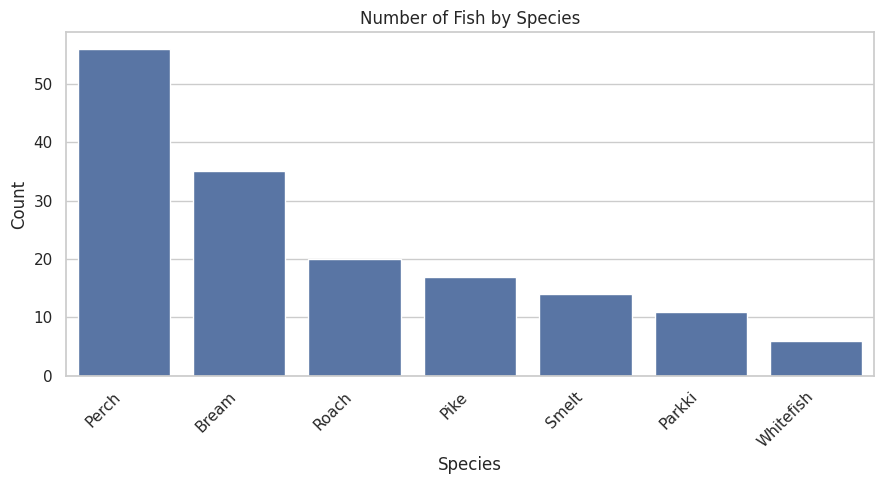

In [12]:
species_counts = df['Species'].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=species_counts.index,
    y=species_counts.values
)

plt.title('Number of Fish by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()




**결과 확인 및 해석**

`Perch`가 가장 많고 `Whitefish`가 가장 적습니다. 범주별 표본 수 차이가 크므로 전체 성능만으로는 표본이 적은 어종의 예측 품질을 판단하기 어렵다는 점을 기억해야 합니다.

### 무게 분포 시각화 · 약 6분

**시나리오**  
평균이나 중앙값 하나만으로는 값이 어느 구간에 몰렸는지, 좌우가 대칭인지, 긴 꼬리가 있는지 알기 어렵습니다. 무게를 구간별로 세어 전체 분포의 모양을 확인하면 대표값 선택과 이상값 판단의 근거를 얻을 수 있습니다.

**AI에게 요청할 프롬프트**

> `df`의 `Weight` 값이 어느 구간에 많이 몰려 있는지 알 수 있도록 20개 구간의 빈도 막대와 부드러운 분포 곡선을 한 그래프에 그려 주세요. 제목과 축 이름도 표시해 주세요.

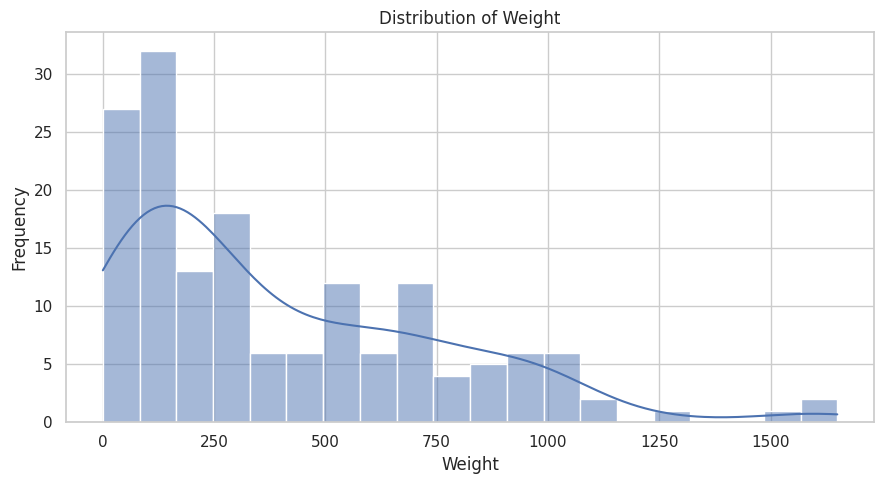

In [13]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='Weight',
    bins=20,
    kde=True
)

plt.title('Distribution of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()




**결과 확인 및 해석**

낮은 무게 구간에 관측치가 많고 오른쪽 꼬리가 깁니다. 이런 분포에서는 큰 값의 영향을 많이 받는 평균만 보기보다 중앙값과 사분위수를 함께 확인하는 것이 좋습니다.

### 길이와 무게의 관계 시각화 · 약 8분

**시나리오**  
향후 무게 예측에 길이가 유용한 입력인지 알아보려면 두 값이 함께 증가하는지 확인해야 합니다. 동시에 같은 길이에서도 어종에 따라 무게가 달라지는지 보면 `Species` 정보가 필요한 이유도 판단할 수 있습니다.

**AI에게 요청할 프롬프트**

> `df`에서 `Length1`과 `Weight`의 관계를 각 생선을 하나의 점으로 나타내고, 어종마다 점의 색을 다르게 해 주세요. 점이 너무 겹치지 않게 약간 투명하게 만들고 그래프 밖에 어종 범례를 표시해 주세요.

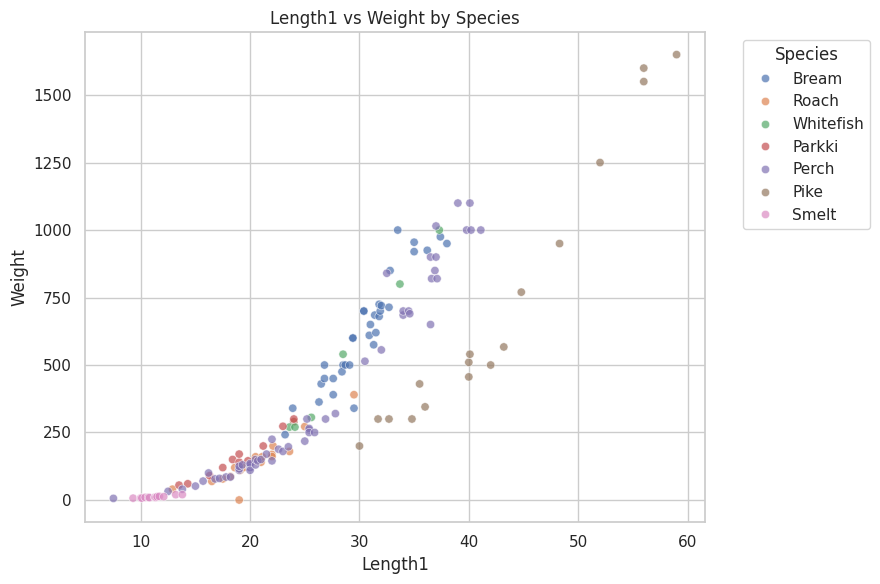

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Length1',
    y='Weight',
    hue='Species',
    alpha=0.7
)

plt.title('Length1 vs Weight by Species')
plt.xlabel('Length1')
plt.ylabel('Weight')

plt.legend(
    title='Species',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()




**결과 확인 및 해석**

길이가 증가할수록 무게도 대체로 증가하지만 하나의 직선만으로 모든 어종을 설명하기는 어렵습니다. 같은 길이에서도 어종별 체형 차이가 있으므로 길이뿐 아니라 어종도 중요한 입력 후보입니다.

### 어종별 폭의 대표값 비교 · 약 8분

**시나리오**  
앞의 `countplot`은 범주별 데이터 개수를 막대 높이로 나타냈습니다. 이번에는 어종마다 여러 개씩 존재하는 폭 측정값을 하나의 대표값으로 요약해 비교하려고 합니다. `barplot`은 원본 데이터와 범주형 변수, 수치형 변수를 전달하면 범주별 수치의 대표값을 내부에서 집계해 막대로 그립니다. 기본 대표값은 평균이지만, 치수 분포가 치우치거나 큰 값이 섞여 있을 가능성을 고려해 여기서는 중앙값을 사용합니다.

**AI에게 요청할 프롬프트**

> `df`의 원본 데이터를 사용하여 어종별 `Width`의 중앙값을 막대로 비교해 주세요. 어종별 중앙값 표를 미리 만들지 말고 그래프를 그리는 과정에서 중앙값을 계산하며, 오차 구간은 표시하지 말고 어종 이름이 겹치지 않게 해 주세요.

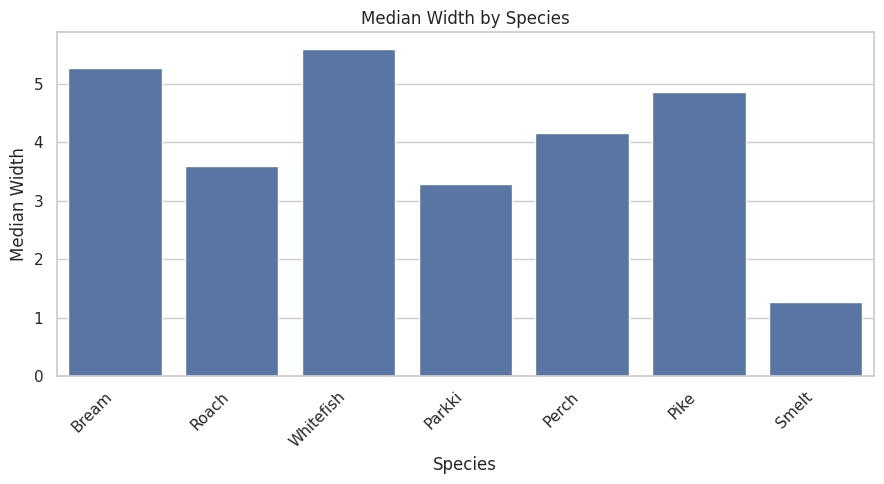

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Species',
    y='Width',
    estimator=np.median,
    errorbar=None
)

plt.title('Median Width by Species')
plt.xlabel('Species')
plt.ylabel('Median Width')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()




**결과 확인 및 해석**

`countplot`은 범주에 속한 관측치의 개수를 세어 막대 높이로 나타냅니다. 반면 `barplot`은 범주별 수치형 변수의 대표값을 계산해 막대 높이로 나타내며, 기본값은 평균입니다. 여기서는 원본 `df`를 그대로 전달하고 `estimator='median'`을 지정했기 때문에 Seaborn이 어종별 `Width` 중앙값을 내부에서 계산합니다. 별도의 집계표를 먼저 만들 필요가 없습니다.

### 어종별 무게 분포 비교 · 약 8분

**시나리오**  
대표값만 비교하면 같은 중앙값을 가진 두 어종의 퍼짐 정도나 이상값 후보를 구분할 수 없습니다. 어종별 중앙값·사분위 범위·전체적인 퍼짐을 한 번에 비교해 어종 사이 차이와 그룹 내부 변동을 함께 살펴봅니다.

**AI에게 요청할 프롬프트**

> `df`의 어종별 `Weight` 분포를 중앙값, 사분위 범위, 수염과 이상값 후보가 함께 보이는 상자 형태의 그래프로 비교해 주세요. 무게 중앙값이 큰 어종부터 배치하고 어종 이름이 겹치지 않게 해 주세요.

**결과 확인 및 해석**

상자의 가운데 선은 중앙값, 상자의 아래와 위는 각각 1사분위수와 3사분위수입니다. 별도 점으로 표시된 값은 통계적 이상값 후보일 뿐 자동으로 삭제해야 하는 오류는 아닙니다. 실제 오류인지 판단하려면 원자료와 업무 맥락이 필요합니다.

### 수치형 변수의 상관관계 시각화 · 약 9분

**시나리오**  
무게와 함께 움직이는 측정값은 유용한 입력 후보가 될 수 있습니다. 반대로 길이 변수끼리 거의 같은 움직임을 보인다면 중복된 정보를 여러 번 제공할 수 있으므로, 모든 수치형 변수 쌍의 선형 관계를 한눈에 비교합니다.

**AI에게 요청할 프롬프트**

> `df`의 모든 수치형 컬럼 사이에서 피어슨 상관계수를 계산해 주세요. -1부터 1까지의 값을 색으로 구분하고 각 칸에 소수 둘째 자리까지 숫자를 표시하는 정사각형 표 형태의 그래프로 그려 주세요.

**결과 확인 및 해석**

`Weight`는 길이·폭과 강한 양의 상관을 보입니다. `Length1`, `Length2`, `Length3`끼리는 상관계수가 약 0.99 이상으로 매우 높아 서로 비슷한 정보를 담고 있습니다. 상관관계는 선형 관계의 강도이며 인과관계를 뜻하지 않습니다.

## 4. 데이터 품질 문제 처리

EDA에서 발견한 비정상 타겟과 결측치를 처리합니다. 전처리는 데이터를 실제로 바꾸는 작업이므로 원본을 보존하고, 처리 전후를 숫자로 비교해 의도한 부분만 바뀌었는지 확인해야 합니다.

### 원본 보호와 비정상 타겟 확인 · 약 5분

**시나리오**  
전처리 과정에서 값을 잘못 바꾸거나 행을 과도하게 제거할 수 있으므로 처음 불러온 `df`는 비교 기준으로 남겨 둡니다. 별도의 전처리용 데이터에서 실제 생선 무게로 보기 어려운 0 이하의 값을 찾아, 어떤 행인지 다른 측정값과 함께 확인합니다.

**AI에게 요청할 프롬프트**

> 이후 전처리에서 처음 불러온 `df`가 바뀌지 않도록 같은 내용을 가진 별도의 데이터 `fish`를 만들어 주세요. `fish`에서 무게가 0 이하인 행을 찾아 그 행의 모든 컬럼을 보여 주세요.

**결과 확인 및 해석**

`df`와 내용이 같은 독립적인 `fish`를 만들면 이후 `fish`를 수정해도 원본과 비교할 수 있습니다. 확인 결과 19cm 생선의 무게가 0g인 1행은 정상 관측으로 보기 어렵습니다. 타겟을 평균이나 중앙값으로 채우면 예측해야 할 정답을 임의로 만들어내므로 그렇게 처리하지 않습니다.

### 비정상 타겟 행 제외 · 약 3분

**시나리오**  
원자료를 다시 확인할 수 없는 상황에서는 신뢰할 수 없는 타겟을 임의로 수정하기보다 분석 대상에서 제외하는 편이 안전합니다. 조건에 맞는 행만 남긴 뒤 원본과 행 수를 비교해 정확히 한 행만 빠졌는지 확인합니다.

**AI에게 요청할 프롬프트**

> 전처리용 `fish`에서 무게가 0보다 큰 행만 남겨 주세요. 처음 불러온 `df`는 그대로 유지하고, 처리 전후의 행 수와 열 수를 비교해 주세요.

**결과 확인 및 해석**

행 수가 159개에서 158개로 줄어듭니다. 조건으로 골라낸 결과를 독립적인 데이터로 만들어 두면 이후 컬럼 수정이 원본이나 임시 뷰에 예기치 않게 영향을 주는 문제를 피할 수 있습니다.

### 어종별 중앙값으로 결측치 처리 · 약 10분

**시나리오**  
측정값이 비어 있는 행을 모두 삭제하면 작은 데이터에서 정보 손실이 커집니다. 또한 어종마다 체형이 다르므로 전체 생선의 대표값으로 채우면 해당 어종의 특성이 흐려질 수 있습니다. 결측치가 있는 세 치수는 같은 어종에서 관측된 중앙값으로 채우고 처리 전후를 비교합니다.

**AI에게 요청할 프롬프트**

> `fish`의 `Length2`, `Length3`, `Height`에 있는 결측치를 각 행과 같은 어종에서 계산한 중앙값으로 채워 주세요. 값을 채우기 전과 후에 세 컬럼의 결측치 개수를 각각 보여 주세요.

**결과 확인 및 해석**

코드의 `groupby`는 같은 어종끼리 묶고, `transform`은 각 행에 대응하는 어종별 중앙값을 원래 데이터와 같은 길이로 돌려줍니다. 그 결과 각 빈칸을 같은 어종의 대표적인 치수로 채울 수 있습니다. 처리 후 세 컬럼의 결측치가 모두 0인지 확인합니다.

### 전처리 중간 검증 · 약 4분

**시나리오**  
코드가 오류 없이 끝났다는 사실만으로 전처리가 올바르다고 볼 수는 없습니다. 행 수, 결측치, 중복행, 무게의 최솟값을 한 번에 점검해 의도하지 않은 행 삭제나 새로운 문제 발생 여부를 확인합니다.

**AI에게 요청할 프롬프트**

> 현재 `fish`의 행 수와 열 수, 전체 결측치 수, 완전히 중복된 행 수, 무게의 최솟값을 한 번에 확인할 수 있도록 출력해 주세요.

**결과 확인 및 해석**

기대 결과는 158행, 7열, 전체 결측치 0개, 중복행 0개, 무게 최솟값 5.9g입니다. 예상값과 다르면 다음 단계로 넘어가기 전에 어느 처리에서 달라졌는지 찾아야 합니다.

## 5. 파생변수 생성과 불필요한 컬럼 정리

상관관계 분석에서 세 길이 변수가 서로 매우 비슷한 정보를 담는다는 사실을 확인했습니다. 세 값을 대표하는 새 변수를 만들고 기존 컬럼을 정리하면서, 정보를 결합해 새 컬럼을 만드는 과정과 필요 없는 컬럼을 제거하는 과정을 연습합니다.

### 평균 길이 파생컬럼 생성 · 약 6분

**시나리오**  
세 길이는 측정 기준이 다르지만 모두 생선의 크기를 나타냅니다. 세 값을 행별로 평균 내어 대표 길이를 만들면 여러 치수를 한 개의 이해하기 쉬운 변수로 요약할 수 있습니다.

**AI에게 요청할 프롬프트**

> `fish`의 각 행에서 `Length1`, `Length2`, `Length3`의 평균을 계산해 `Length_mean`이라는 새 컬럼으로 추가해 주세요. 계산이 맞는지 확인할 수 있도록 네 개의 관련 컬럼에서 처음 5행을 보여 주세요.

**결과 확인 및 해석**

코드의 `axis=1`은 같은 행 안에서 여러 컬럼의 평균을 계산한다는 뜻입니다. 파생변수는 기존 정보를 단순 복사하는 것이 아니라 분석 목적에 맞게 결합하거나 변환해 새로운 정보를 만드는 과정입니다.

### 중복 정보가 큰 컬럼 정리 · 약 5분

**시나리오**  
대표 길이를 만든 뒤 원래 세 길이를 모두 유지하면 비슷한 정보가 네 번 들어갑니다. 높은 상관관계를 확인했다는 근거를 바탕으로 원래 길이 컬럼을 뺀 별도 데이터를 만들고, 제거 전후 컬럼을 비교해 필요한 컬럼만 빠졌는지 검증합니다.

**AI에게 요청할 프롬프트**

> `fish`에서 `Length1`, `Length2`, `Length3`만 제외한 새 데이터 `fish_reduced`를 만들어 주세요. 원래 데이터와 새 데이터의 컬럼 목록을 비교하고 새 데이터의 처음 5행도 보여 주세요. 기존 `fish`는 바꾸지 마세요.

**결과 확인 및 해석**

최종 컬럼은 `Species`, `Weight`, `Height`, `Width`, `Length_mean`입니다. 실제 프로젝트에서는 컬럼 제거 전후의 모델 성능까지 비교해 타당성을 판단해야 합니다. 여기서는 상관관계로 확인한 높은 중복성을 줄이는 예시로 수행합니다.

## 6. 범주형 변수 인코딩

많은 머신러닝 알고리즘은 `Species` 같은 문자열을 그대로 입력받지 못합니다. 범주를 숫자로 바꾸는 두 방식을 비교하고, 단순한 숫자 부여가 어종 사이에 존재하지 않는 순서를 만들 수 있다는 점을 확인합니다.

### 어종에 정수 코드 부여 · 약 8분

**시나리오**  
각 어종을 하나의 숫자로 바꾸면 컬럼 하나만으로 간단히 표현할 수 있습니다. 하지만 결과를 해석하려면 어떤 숫자가 어떤 어종인지 대응표가 필요하고, 숫자의 크기가 실제 순서를 뜻하는지도 따져봐야 합니다.

**AI에게 요청할 프롬프트**

> `fish_reduced`의 어종 이름을 알파벳순으로 정리하고 0부터 차례로 숫자를 부여해 주세요. 원본은 유지하면서 `fish_integer`라는 별도 데이터에 `Species_code` 컬럼을 추가하고, 어종과 코드의 대응표도 보여 주세요.

**결과 확인 및 해석**

정수 인코딩은 간단하지만 모델이 코드 6이 코드 1보다 크거나 멀다는 가짜 순서 관계를 학습할 수 있습니다. 어종은 순서가 없는 명목형 범주이므로 최종 입력에는 원핫 인코딩이 더 적합합니다.

### 어종을 여러 개의 0·1 컬럼으로 표현 · 약 8분

**시나리오**  
어종 사이에는 대소나 순서가 없으므로 각 어종을 독립적인 컬럼으로 표현하는 편이 자연스럽습니다. 해당 어종이면 1, 아니면 0이 되도록 바꾸면 모델이 코드 숫자 사이의 거리를 의미로 오해하지 않습니다.

**AI에게 요청할 프롬프트**

> `fish_reduced`의 `Species`를 어종마다 하나씩 만들어지는 0과 1의 컬럼들로 바꿔 주세요. 새 컬럼 이름은 `Species_어종명` 형태로 만들고 값은 정수로 저장하며, 결과를 `fish_encoded`에 담아 변환 전후의 행 수·열 수와 처음 5행을 보여 주세요.

**결과 확인 및 해석**

문자열 `Species` 한 개가 7개의 0·1 컬럼으로 바뀝니다. 절편이 있는 선형모델에서는 기준 범주 하나를 제외할 수도 있지만, 여기서는 각 어종이 어떻게 별도 컬럼으로 표현되는지 명확히 보기 위해 7개를 모두 유지합니다.

## 7. 수치형 입력 변수 스케일링

길이·높이·폭은 단위와 범위가 다릅니다. 값의 범위가 큰 변수가 거리 계산이나 규제가 있는 모델에 과도한 영향을 주지 않도록 연속형 입력의 척도를 맞춥니다. 예측할 정답인 `Weight`와 이미 0·1인 어종 컬럼은 변환하지 않습니다.

> **데이터 누수 주의:** 실제 모델 평가에서는 먼저 학습·평가 데이터를 분리하고, 척도 변환 기준은 학습 데이터에서만 계산해야 합니다. 여기서는 모델링 전 단계에서 변환 원리와 결과를 확인하기 위해 전체 데이터를 사용합니다.

### 연속형 입력 변수 표준화 · 약 10분

**시나리오**  
`Length_mean`, `Height`, `Width`는 단위와 값의 범위가 서로 다릅니다. 세 변수의 평균이 0, 표준편차가 1에 가까워지도록 변환하면 서로 다른 척도를 공통 기준에서 비교할 수 있습니다. 무게와 어종 0·1 컬럼은 의미와 단위를 보존합니다.

**AI에게 요청할 프롬프트**

> `fish_encoded`는 그대로 남겨 두고 `fish_prepared`라는 전처리 결과를 만들어 주세요. `Length_mean`, `Height`, `Width` 세 입력 변수만 각각 평균 0, 표준편차 1이 되도록 변환하고, `Weight`와 이름이 `Species_`로 시작하는 0·1 컬럼은 바꾸지 마세요. 결과의 처음 5행도 보여 주세요.

**결과 확인 및 해석**

`StandardScaler`는 각 값에서 평균을 빼고 표준편차로 나눕니다. 값의 상대적 순서는 유지되지만 원래 단위는 사라집니다. 트리 계열 모델에는 보통 필요하지 않지만 거리 기반 모델이나 규제가 있는 선형모델에서는 특히 중요합니다.

### 스케일링 결과 검증 · 약 6분

**시나리오**  
변환 코드가 실행되었더라도 대상 컬럼만 바뀌었는지 확인해야 합니다. 연속형 입력의 평균과 표준편차가 목표에 맞는지, 타겟의 단위와 어종 컬럼의 0·1 값이 그대로 남았는지를 함께 점검합니다.

**AI에게 요청할 프롬프트**

> `fish_prepared`에서 표준화한 세 입력 변수의 평균과 모집단 표준편차를 표로 보여 주세요. `Weight`의 최솟값과 최댓값도 확인하고, 이름이 `Species_`로 시작하는 모든 컬럼에는 0과 1만 남아 있는지 점검해 주세요.

**결과 확인 및 해석**

세 연속형 입력의 평균은 거의 0, 모집단 표준편차는 1이 됩니다. `Weight`는 원래 g 단위를 유지하고 어종 컬럼에는 0과 1만 있어야 합니다. 이 검증으로 변환 대상과 제외 대상이 의도대로 처리되었는지 확인합니다.

## 8. 머신러닝 입력 직전 상태 만들기

모델 학습은 하지 않습니다. 예측에 사용할 입력과 예측할 정답을 분리하고, 다음 단계에서 다시 불러올 수 있도록 전처리 결과를 저장하는 데서 마칩니다.

### 입력 변수와 타겟 분리 · 약 4분

**시나리오**  
머신러닝에서는 모델이 참고할 입력과 맞혀야 할 정답을 구분해야 합니다. `Weight`가 실수로 입력에 남으면 정답을 미리 알려주는 심각한 데이터 누수가 생기므로, 분리 후 크기·결측치·자료형까지 확인합니다.

**AI에게 요청할 프롬프트**

> `fish_prepared`에서 예측 대상인 `Weight`만 `y`에 저장하고, `Weight`를 제외한 나머지 컬럼은 `X`에 저장해 주세요. 두 결과의 크기와 결측치 수를 확인하고 `X`의 각 컬럼 자료형도 보여 주세요. 원래 `fish_prepared`는 유지해 주세요.

**결과 확인 및 해석**

최종 결과는 158개 행의 `X`와 `y`이며 결측치가 없어야 합니다. `X`의 모든 컬럼이 수치형이고 `Weight`가 포함되지 않았으므로 대부분의 머신러닝 모델에 입력할 수 있는 형태입니다.

### 전처리 결과 저장 · 약 3분

**시나리오**  
전처리가 끝난 데이터를 파일로 저장하면 다음 모델링 단계에서 같은 과정을 반복하지 않고 결과를 확인하거나 공유할 수 있습니다. 저장 과정에서 데이터프레임의 행 번호가 불필요한 새 컬럼으로 들어가지 않도록 하고, 저장 직전 품질도 다시 확인합니다.

**AI에게 요청할 프롬프트**

> `fish_prepared`를 현재 폴더에 `fish_market_preprocessed.csv`라는 이름으로 저장해 주세요. 데이터프레임의 행 번호는 파일에 넣지 말고, 저장한 파일명과 데이터 크기, 전체 결측치 수도 출력해 주세요.

**결과 확인 및 해석**

저장 파일에는 데이터프레임의 행 번호가 별도 컬럼으로 추가되지 않습니다. 다음 모델링 단계에서는 원자료를 학습·평가 세트로 먼저 나눈 뒤, 학습 세트에서 계산한 전처리 기준을 평가 세트에 적용하는 파이프라인을 구성해야 합니다.

## 마무리 점검

이번 실습에서 자연어로 설명한 분석 의도가 다음 코드로 변환되었습니다.

- 파일을 읽고 처음·마지막 데이터, 크기, 자료형, 기술통계를 확인
- 한 개·여러 개 열 선택, 조건 필터링, 이름·위치 기준 선택, 정렬
- 범주별 빈도와 그룹별 중앙값·사분위수 계산
- 어종별 개수, 무게 분포, 길이와 무게의 관계, 그룹별 대표값과 분포, 상관관계 시각화
- 원본을 보존한 채 비정상 타겟 제거와 어종별 중앙값 결측치 대체
- 대표 길이 파생컬럼 생성과 중복 정보가 큰 컬럼 정리
- 정수 인코딩과 원핫 인코딩 비교
- 수치형 입력 변수 표준화와 변환 결과 검증
- 최종 `X`, `y` 분리와 CSV 저장
